# Exploratory data analysis: SPY daily history

**Author:** Paritosh Dwivedi

Stage 08 of the Weekly ETF Risk Monitor. This notebook profiles the dataset the model is built on and
records what each finding implies for feature engineering and modeling. It reads committed artifacts
only and writes nothing.

In [1]:
# --- run me first: makes this notebook work wherever it lives ---
import os
import sys
from pathlib import Path

if Path.cwd().name == "notebooks":
    os.chdir("..")
ROOT = Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import json

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from src.eda import eda_summary

sns.set_theme(style="whitegrid")
metrics = json.loads((ROOT / "reports/metrics.json").read_text())
df = pd.read_parquet(ROOT / metrics["data"]["model_dataset_file"])
print("working from:", ROOT.name)
print("rows:", len(df), "| span:", metrics["data"]["date_start"], "to", metrics["data"]["date_end"])

working from: project
rows: 4184 | span: 2010-01-04 to 2026-08-21


## 1. Structure and missingness

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4184 entries, 0 to 4183
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   date                       4184 non-null   datetime64[ns]
 1   open                       4184 non-null   float64       
 2   high                       4184 non-null   float64       
 3   low                        4184 non-null   float64       
 4   close                      4184 non-null   float64       
 5   adjusted_close             4184 non-null   float64       
 6   volume                     4184 non-null   int64         
 7   dividends                  4184 non-null   float64       
 8   stock_splits               4184 non-null   float64       
 9   daily_return               4183 non-null   float64       
 10  log_return                 4183 non-null   float64       
 11  return_lag_1               4182 non-null   float64       
 12  return

In [3]:
missing = df.isna().sum()
display(missing[missing > 0].to_frame("missing").T)
print("columns with no missing values:", int((missing == 0).sum()), "of", df.shape[1])

,daily_return,log_return,return_lag_1,return_lag_5,rolling_return_5,rolling_vol_5,rolling_vol_20,ewma_vol_20,vol_ratio,volume_z_20,target_next_week_vol,target_next_week_return,return_outlier_score
missing,1,1,2,6,5,5,20,2,20,19,5,5,1


columns with no missing values: 14 of 27


Missingness is entirely structural: it sits at the head of the frame where trailing windows have not
filled yet, and at the tail where the five-session forward target cannot exist. Nothing is missing in
the middle, so there is no data-quality gap to repair — only rows the model cannot use.

## 2. Numeric profile

In [4]:
summary = eda_summary(df)
profile = summary["numeric_profile"].loc[
    [
        "daily_return",
        "rolling_vol_5",
        "rolling_vol_20",
        "ewma_vol_20",
        "vol_ratio",
        "drawdown",
        "volume_z_20",
        "target_next_week_vol",
    ],
    ["mean", "std", "min", "50%", "max", "skew", "kurtosis"],
]
display(profile.round(4))

,mean,std,min,50%,max,skew,kurtosis
daily_return,0.0006,0.0108,-0.1094,0.0007,0.1050,-0.3299,12.0070
rolling_vol_5,0.1374,0.1069,0.0068,0.1130,1.4233,3.9975,30.6168
rolling_vol_20,0.1465,0.0909,0.0319,0.1240,0.9392,3.5741,21.8523
ewma_vol_20,0.1476,0.0886,0.0175,0.1240,0.9577,3.4605,20.2481
vol_ratio,0.9423,0.3714,0.0993,0.9102,2.0743,0.3739,-0.3617
drawdown,-0.0379,0.0503,-0.3372,-0.0162,0.0000,-1.8476,3.3724
volume_z_20,-0.0122,1.0609,-2.4638,-0.2278,3.8424,0.9032,0.6512
target_next_week_vol,0.1382,0.1015,0.0131,0.1161,1.3421,3.8841,29.0341


## 3. Categorical profile

In [5]:
# The dataset is numeric by construction, so derive the categorical view the risk decision uses:
# a volatility regime band cut at the documented training-period threshold.
threshold = metrics["models"]["risk_threshold_annualized_vol"]
regime = pd.cut(
    df["rolling_vol_20"],
    bins=[-float("inf"), threshold * 0.6, threshold, float("inf")],
    labels=["calm", "normal", "elevated"],
)
df = df.assign(vol_regime=regime)
counts = df["vol_regime"].value_counts(dropna=False).sort_index()
display(pd.DataFrame({"sessions": counts, "share": (counts / counts.sum()).round(3)}))
print("elevated threshold: %.1f%% annualized" % (threshold * 100))

,sessions,share
vol_regime,,
calm,1582,0.378
normal,1603,0.383
elevated,979,0.234
NaN,20,0.005


elevated threshold: 17.8% annualized


Roughly two thirds of sessions sit below the elevated band. Any classifier trained on this will beat a
coin flip by predicting "not elevated" every time, which is exactly why the project reports balanced
accuracy and recall rather than raw accuracy.

## 4. Distributions

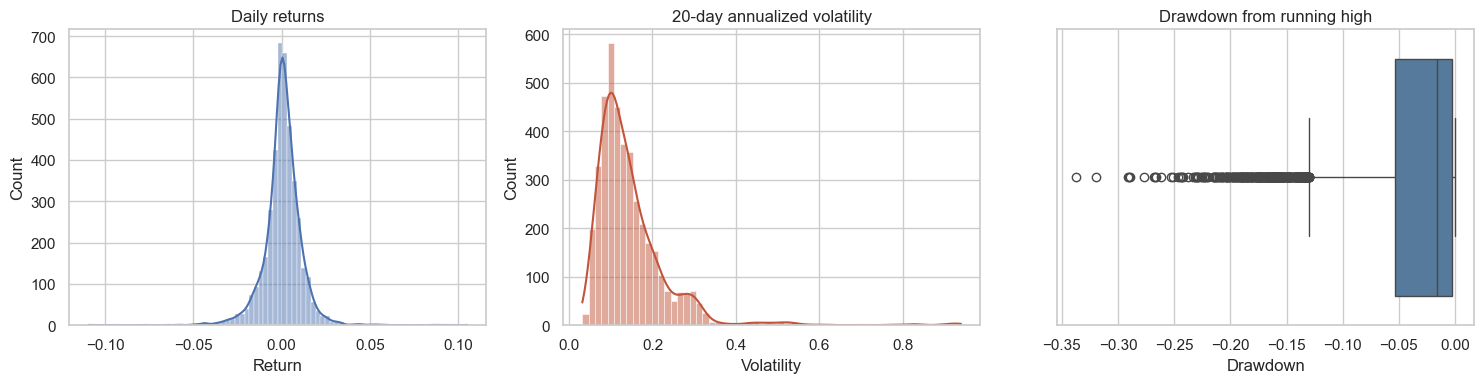

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(df["daily_return"].dropna(), bins=80, kde=True, ax=axes[0])
axes[0].set(title="Daily returns", xlabel="Return")
sns.histplot(df["rolling_vol_20"].dropna(), bins=60, kde=True, ax=axes[1], color="#c1543a")
axes[1].set(title="20-day annualized volatility", xlabel="Volatility")
sns.boxplot(x=df["drawdown"].dropna(), ax=axes[2], color="#4a7ba7")
axes[2].set(title="Drawdown from running high", xlabel="Drawdown")
plt.tight_layout()
plt.show()

Returns are near-symmetric but sharply peaked with long tails: kurtosis of about 12 against 0 for a
normal distribution. Volatility is strongly right skewed, so its mean sits above the typical session.
Drawdown is bounded above at zero and has a long left tail, which is a different shape from anything
else here and a reason to keep it as its own feature.

## 5. Relationships

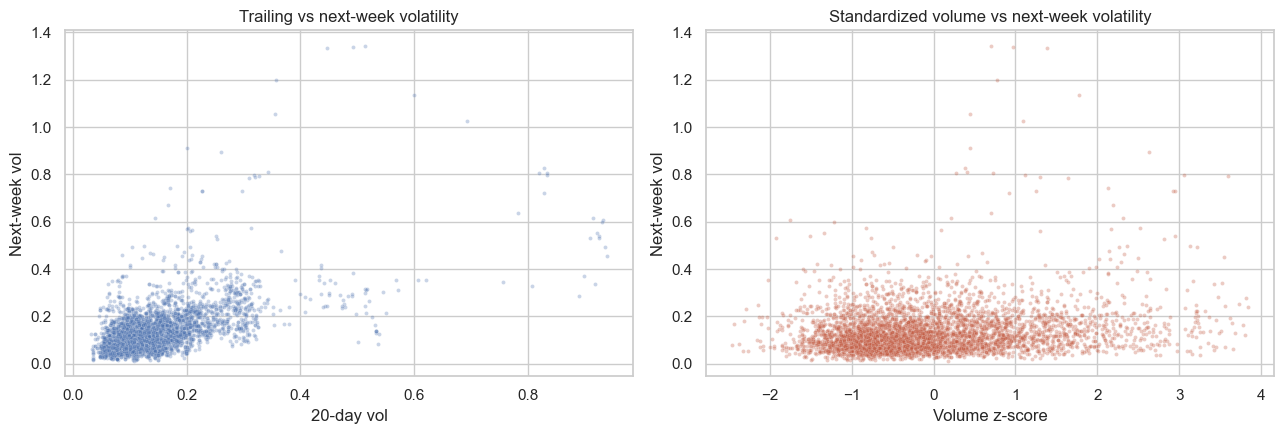

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sample = df.dropna(subset=["rolling_vol_20", "target_next_week_vol", "volume_z_20"])
sns.scatterplot(
    data=sample, x="rolling_vol_20", y="target_next_week_vol", s=8, alpha=0.3, ax=axes[0]
)
axes[0].set(title="Trailing vs next-week volatility", xlabel="20-day vol", ylabel="Next-week vol")
sns.scatterplot(
    data=sample,
    x="volume_z_20",
    y="target_next_week_vol",
    s=8,
    alpha=0.3,
    ax=axes[1],
    color="#c1543a",
)
axes[1].set(
    title="Standardized volume vs next-week volatility",
    xlabel="Volume z-score",
    ylabel="Next-week vol",
)
plt.tight_layout()
plt.show()

Trailing volatility tracks next-week volatility closely along the diagonal, which is the persistence
the baseline exploits. The volume relationship is much looser but fans out: high-volume sessions are
rarely followed by calm weeks, even though low volume says little. That asymmetry is worth a feature
even though the correlation is modest.

## 6. Over time

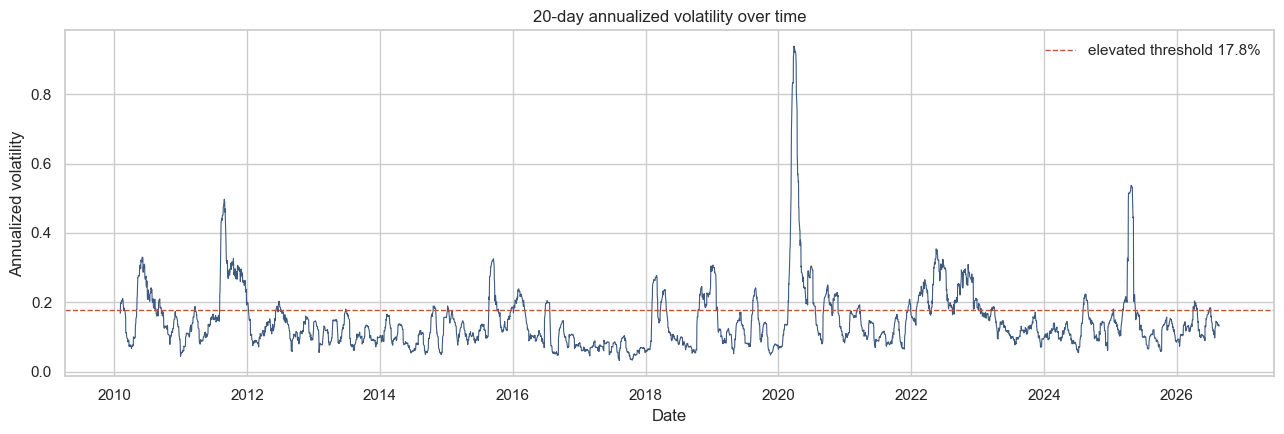

In [8]:
fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(df["date"], df["rolling_vol_20"], linewidth=0.8, color="#3d5a80")
ax.axhline(
    threshold,
    color="#c1543a",
    linestyle="--",
    linewidth=1,
    label=f"elevated threshold {threshold:.1%}",
)
ax.set(
    title="20-day annualized volatility over time", xlabel="Date", ylabel="Annualized volatility"
)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

**What this shows:** no trend and no seasonality. Volatility is mean-reverting around a low level,
punctuated by sharp clustered spikes — 2010, 2011, 2015, the 2020 dislocation, and 2022. The level is
stable across the whole span; what changes is how often it spikes.

This is the single most important read in the notebook, and it drives two decisions. Because the
series is clustered rather than trending, recent volatility is a strong predictor and any model must
be judged against it. Because the spikes are rare and short, a random train/test split would scatter
pieces of the same episode across both sides and badly overstate performance, so the split must be
chronological and purged.

## 7. Correlation

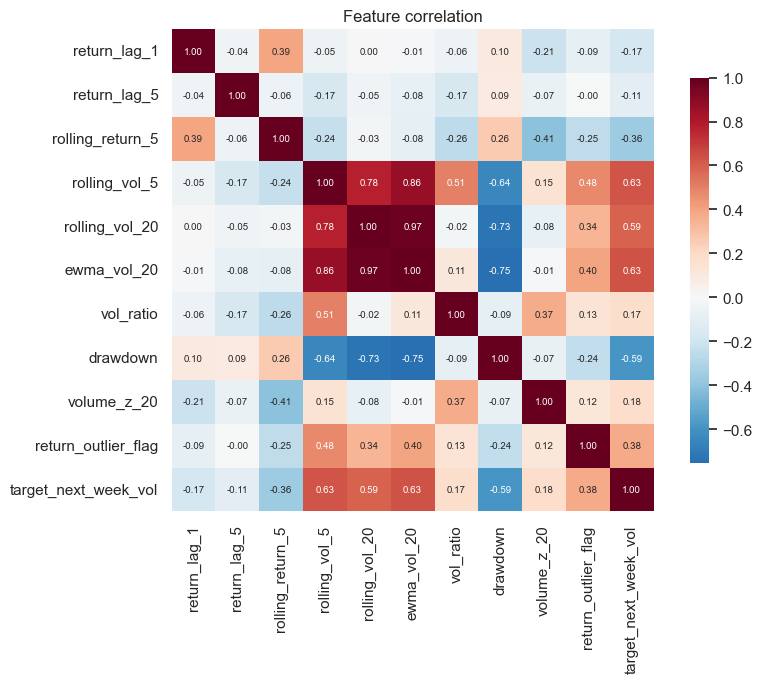

In [9]:
feature_columns = metrics["models"]["feature_columns"]
corr = df[feature_columns + ["target_next_week_vol"]].corr()
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    square=True,
    cbar_kws={"shrink": 0.8},
    annot_kws={"size": 7},
    ax=ax,
)
ax.set_title("Feature correlation")
plt.tight_layout()
plt.show()

In [10]:
display(
    corr["target_next_week_vol"]
    .drop("target_next_week_vol")
    .sort_values(ascending=False)
    .round(3)
    .to_frame("correlation with target")
)

,correlation with target
ewma_vol_20,0.633
rolling_vol_5,0.627
rolling_vol_20,0.588
return_outlier_flag,0.381
volume_z_20,0.182
vol_ratio,0.173
return_lag_5,-0.105
return_lag_1,-0.174
rolling_return_5,-0.359
drawdown,-0.589


The three volatility measures correlate above 0.9 with each other, so they are close to redundant.
Ridge regression is the right choice precisely because it handles that collinearity by shrinking
correlated coefficients together instead of arbitrarily picking one.

## 8. Columns needing attention before feature engineering

In [11]:
display(pd.Series(summary["attention"], name="columns").to_frame())

,columns
high_missing,[]
near_zero_variance,"[stock_splits, forecast_horizon_days, short_fe..."
dominant_category,[]


The flagged columns are constants recording the run configuration — horizon and window sizes — not
measurements. They carry no variance and are correctly excluded from the feature set.

## Top three insights

1. **Volatility clusters and mean-reverts; it does not trend.** Recent volatility is therefore a
   strong baseline, and beating it is the real test of the model.
2. **Returns are fat-tailed, kurtosis about 12.** Tail days carry the risk information, so they are
   flagged and kept rather than removed.
3. **Elevated weeks are roughly one in eight.** Raw accuracy is misleading on this data; balanced
   accuracy and recall are the metrics that mean anything.

## Assumptions and risks

- The regime bands are cut at the documented training-period threshold. A different threshold moves
  the class balance and every classification metric with it.
- Profiling covers the whole history, so a long calm stretch can mask behaviour specific to a
  stressed regime. The calendar-year and walk-forward diagnostics exist to check that.
- Correlations are linear. A weak correlation here does not prove a feature is useless, only that any
  relationship is not straight-line.

## Implications for stage 09

Keep the trailing volatility family but expect collinearity and regularize. Keep drawdown and
standardized volume for the stress information they add. Carry the outlier flag as context. Build no
feature that reads forward of the decision date.